In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pyproj
from pyproj import Transformer
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
import numpy as np
import re
from scipy.optimize import curve_fit
from pandas.errors import EmptyDataError
from pandas.errors import EmptyDataError


<h1>Dataframe creation</h1>

In [2]:
lat_lon_path="/mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/raingage_lat_lon.csv"
coordinate_df=pd.read_csv(lat_lon_path)
buffer=50000

<h1>Transformer setup and dataframe creation</h1>

In [3]:
transformer = Transformer.from_crs("EPSG:4326", "EPSG:26915",always_xy=True)

long,lat=transformer.transform(coordinate_df["Longitude"].to_numpy(), 
                               coordinate_df["Latitude"].to_numpy())
coordinate_df["NAD83_15N_Lat"]=lat
coordinate_df["NAD83_15N_Long"]=long
coordinate_df.to_csv("/mnt/12TB/Sujan/Spatial_correlation/Codes/UTM_OK/01_Correlation_and_Variogram/Stations_df.csv")

<h1>GDF creation using Gage stations</h1>

In [4]:
geometry = [
    Point(xy) for xy in zip(
        coordinate_df["NAD83_15N_Long"],  
        coordinate_df["NAD83_15N_Lat"]     
    )
]

gdf = gpd.GeoDataFrame(
    coordinate_df,
    geometry=geometry,
    crs="EPSG:26915"   # NAD83 UTM 15N
)


<h1>Pilot Location and buffer</h1>

In [5]:
pilot_location_x=-94.665
pilot_location_y=38.915000000000006
pl_long,pl_lat=transformer.transform(pilot_location_x,pilot_location_y)
pl_long,pl_lat

pilot = gpd.GeoDataFrame(
    {"name": ["pilot"]},
    geometry=[Point(pl_long, pl_lat)],
    crs="EPSG:26915"
)

buffer_km = pilot.copy()
buffer_km["geometry"] = buffer_km.geometry.buffer(buffer)  # meters

<h1>Gages, Pilot location and Buffer plotter</h1>

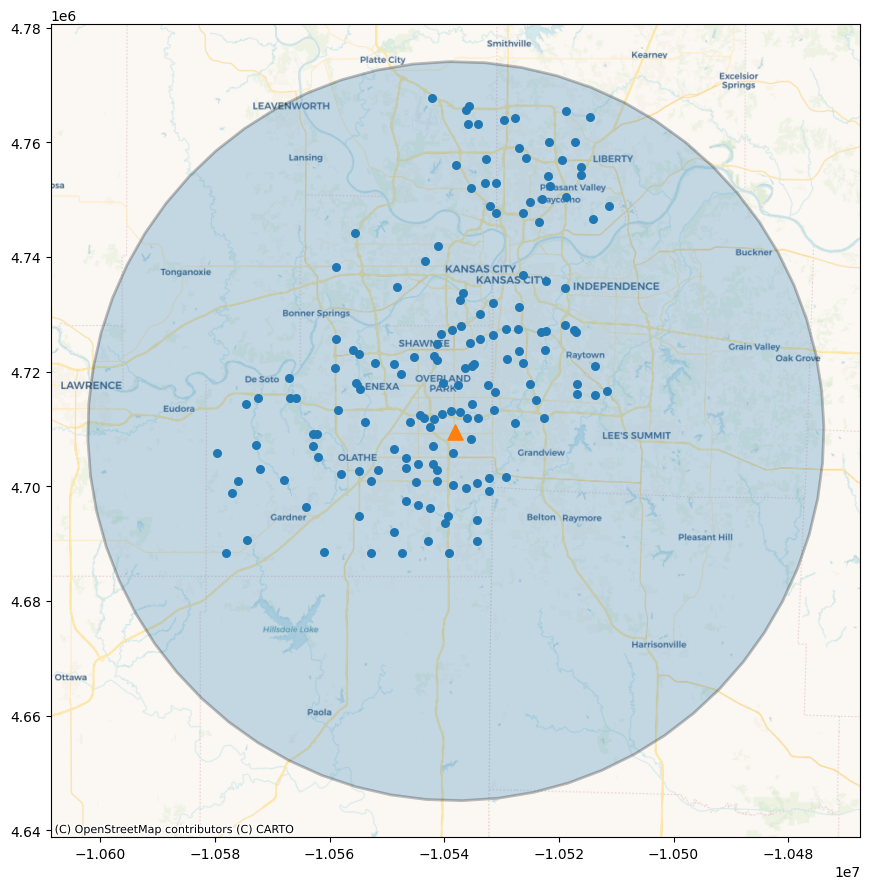

In [6]:
gages_web  = gdf.to_crs(epsg=3857)
pilot_web  = pilot.to_crs(epsg=3857)
buffer_web = buffer_km.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(9, 9))

buffer_web.plot(ax=ax, alpha=0.25, edgecolor="black", linewidth=2)
gages_web.plot(ax=ax, markersize=30)
pilot_web.plot(ax=ax, markersize=120, marker="^")

# Optional: zoom to buffer extent
#minx, miny, maxx, maxy = buffer_web.total_bounds
#pad = 500  # meters in EPSG:3857
#ax.set_xlim(minx - pad, maxx + pad)
#ax.set_ylim(miny - pad, maxy + pad)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager)

plt.tight_layout()
plt.show()

<h1>Point selection using Buffer</h1>

In [7]:
buffer = buffer_km.geometry.iloc[0]

stations_in_km = gdf[gdf.within(buffer)].copy()
print(len(stations_in_km))

158


<h1>Distance matrix creator distance_matrix</h1>

In [8]:
def station_distance_matrix(
    coordinate_df: pd.DataFrame,
    x_col: str = "NAD83_15N_Long",   # Easting (m)
    y_col: str = "NAD83_15N_Lat",    # Northing (m)
    id_col: str = "station_id"      # REQUIRED
) -> pd.DataFrame:
    """
    Returns an NxN distance matrix (meters),
    labeled by station_id.
    """

    if id_col not in coordinate_df.columns:
        raise ValueError(f"{id_col} not found in dataframe.")

    df = coordinate_df.copy()
    print(coordinate_df)
    # Use station_id as labels
    labels = df[id_col].astype(str).values

    # Extract coordinates
    xy = df[[x_col, y_col]].to_numpy(dtype=float)

    # Compute pairwise distances
    dx = xy[:, 0][:, None] - xy[:, 0][None, :]
    dy = xy[:, 1][:, None] - xy[:, 1][None, :]
    dist = np.sqrt(dx**2 + dy**2)

    # Create DataFrame with station IDs as row/col labels
    D = pd.DataFrame(dist, index=labels, columns=labels)

    return D

distance_matrix = station_distance_matrix(coordinate_df, id_col="ID")



        ID   Latitude  Longitude  NAD83_15N_Lat  NAD83_15N_Long
0     3620  39.289337 -94.628969   4.350150e+06   359517.201858
1     3600  39.289198 -94.645378   4.350160e+06   358101.709867
2     7010  39.122898 -94.712834   4.331812e+06   351935.076818
3     2540  39.266930 -94.518555   4.347498e+06   368998.047561
4     2520  39.245375 -94.498011   4.345076e+06   370730.838767
..     ...        ...        ...            ...             ...
153  16036  38.781888 -94.708470   4.293959e+06   351602.677509
154  16047  38.803630 -94.681020   4.296328e+06   354031.492921
155  16034  38.767440 -94.674130   4.292300e+06   354556.280343
156  16005  39.028300 -94.626000   4.321175e+06   359253.959677
157  16050  39.038549 -94.670131   4.322382e+06   355454.657721

[158 rows x 5 columns]


[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/3600.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/2520.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16048.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16035.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16040.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16049.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/2800.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /

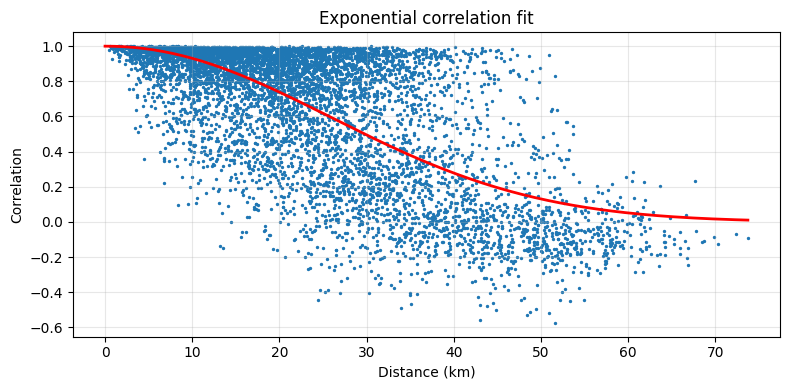

Estimated range a = 35.520 km
Estimated shape b = 2.078


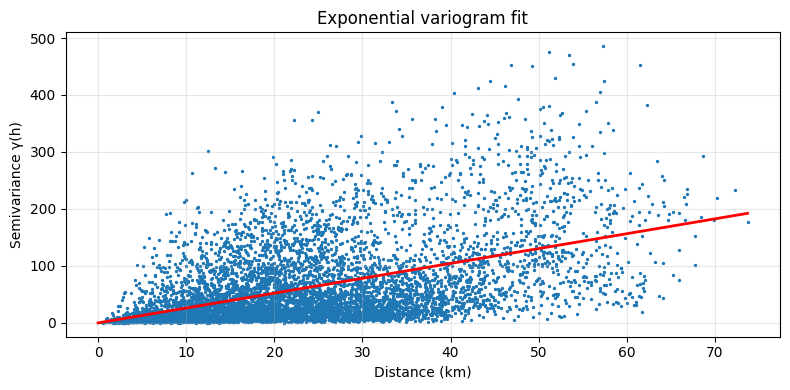

Estimated sill = 2170771.187
Estimated range = 832109.260 km
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/3600.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/2520.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16048.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16035.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16040.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16049.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/280

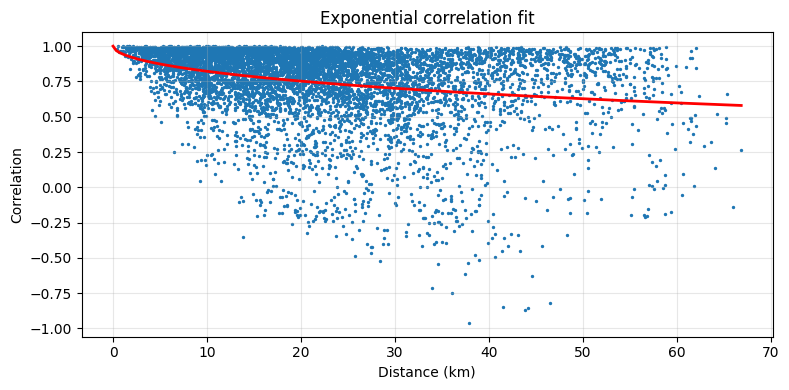

Estimated range a = 206.558 km
Estimated shape b = 0.538


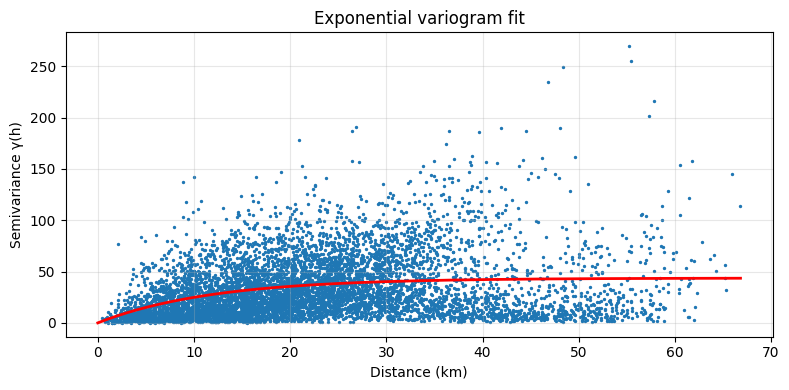

Estimated sill = 43.664
Estimated range = 11.839 km
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/3600.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/2520.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16048.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16035.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16040.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16049.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/2800.hourly_

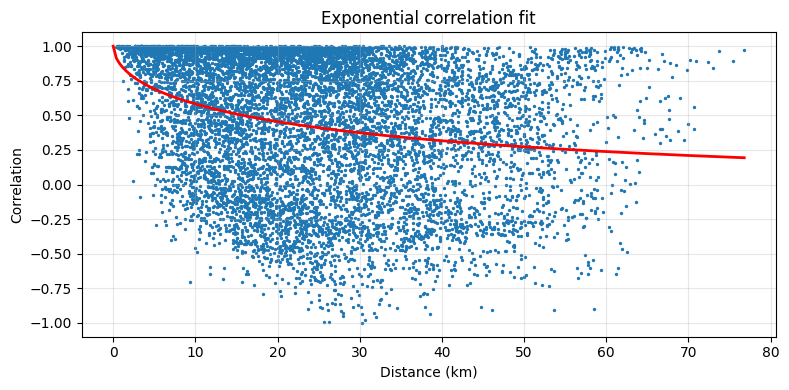

Estimated range a = 30.957 km
Estimated shape b = 0.545


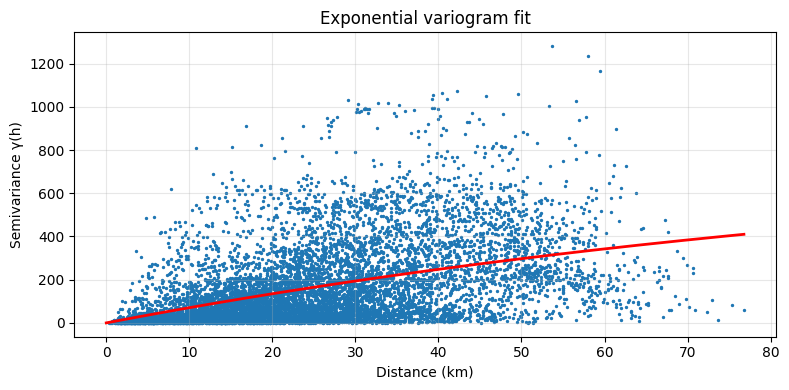

Estimated sill = 830.298
Estimated range = 112.828 km
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/3600.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/2520.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16048.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16035.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16040.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16049.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/2800.hourl

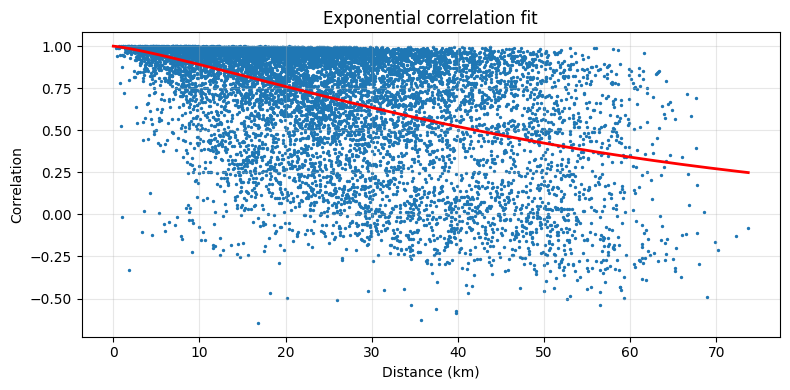

Estimated range a = 56.523 km
Estimated shape b = 1.246


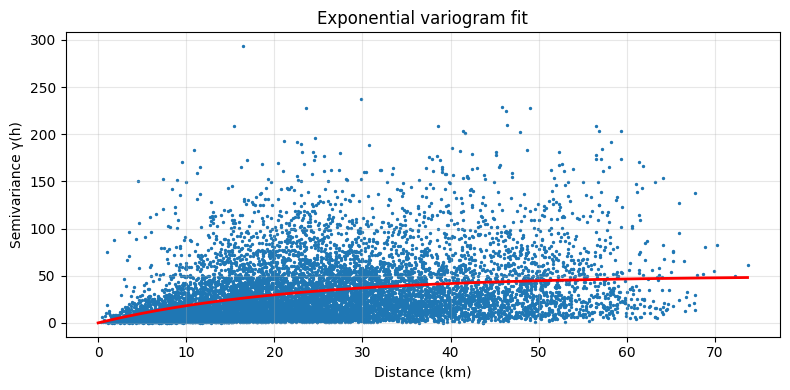

Estimated sill = 49.830
Estimated range = 21.990 km
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/3600.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/2520.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16048.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16035.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16040.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16049.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/2800.hourly_

/mnt/12TB/Sujan/conda_envs/spa_cor/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/mnt/12TB/Sujan/conda_envs/spa_cor/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


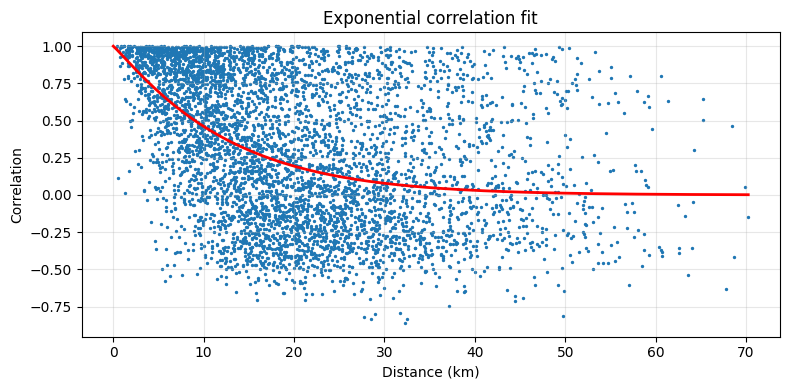

Estimated range a = 12.656 km
Estimated shape b = 1.083


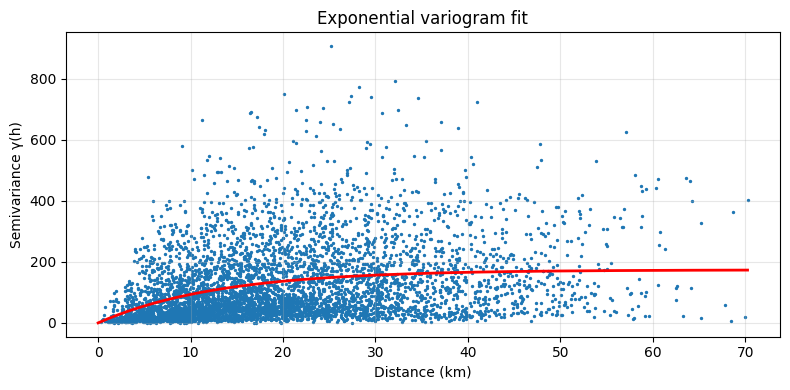

Estimated sill = 173.638
Estimated range = 12.979 km
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/3600.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/2520.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16048.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16035.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16040.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16049.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/2800.hourly

/mnt/12TB/Sujan/conda_envs/spa_cor/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/mnt/12TB/Sujan/conda_envs/spa_cor/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


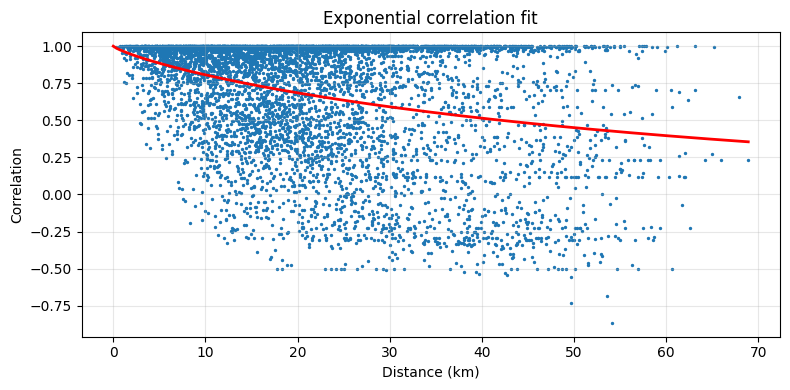

Estimated range a = 66.010 km
Estimated shape b = 0.815


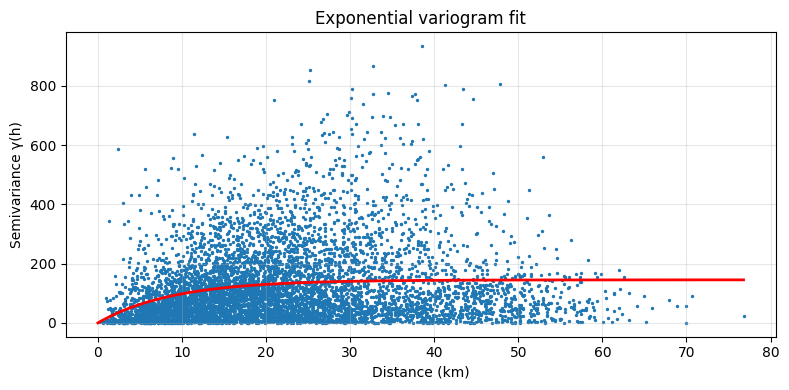

Estimated sill = 145.212
Estimated range = 8.880 km
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/3600.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/2520.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16048.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16035.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16040.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16049.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/2800.hourly_

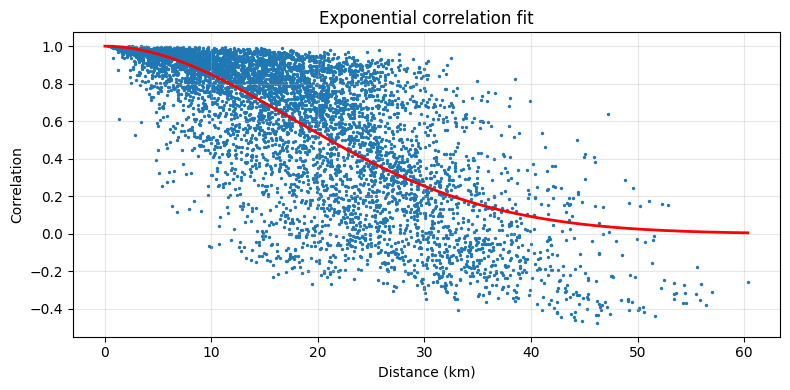

Estimated range a = 25.474 km
Estimated shape b = 1.929


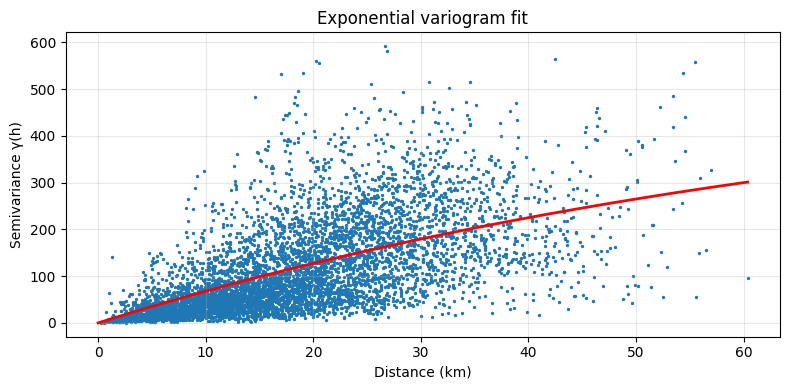

Estimated sill = 547.104
Estimated range = 75.450 km
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/3600.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/2520.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16048.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16035.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16040.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16049.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/2800.hourly

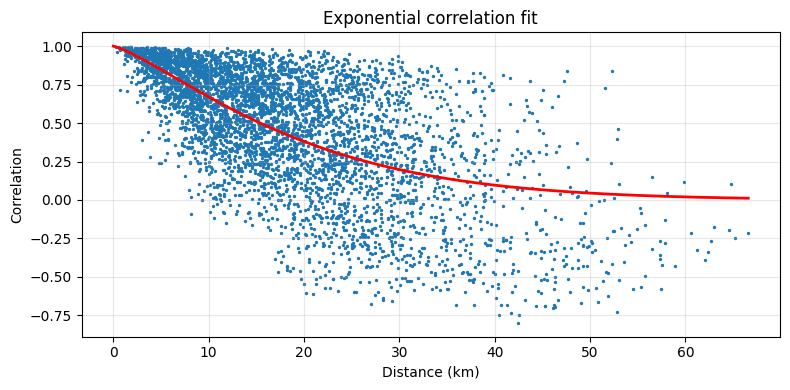

Estimated range a = 20.533 km
Estimated shape b = 1.275


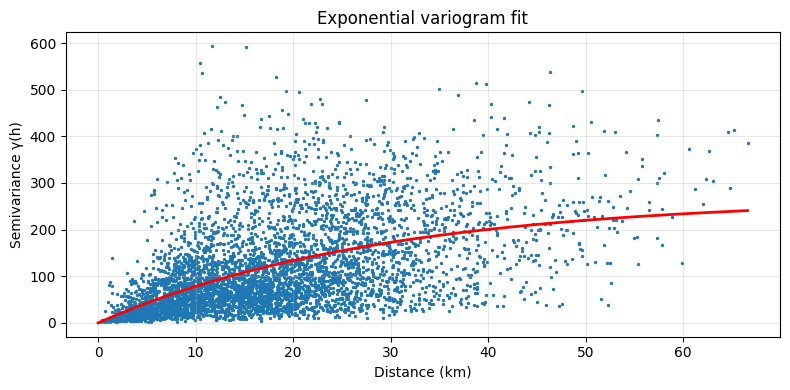

Estimated sill = 267.352
Estimated range = 28.887 km
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/3600.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/2520.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16048.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16035.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16040.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/16049.hourly_mm_missing_ranges.csv
[WARN] Gap file has no rows: /mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time/2800.hourly

/mnt/12TB/Sujan/conda_envs/spa_cor/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/mnt/12TB/Sujan/conda_envs/spa_cor/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


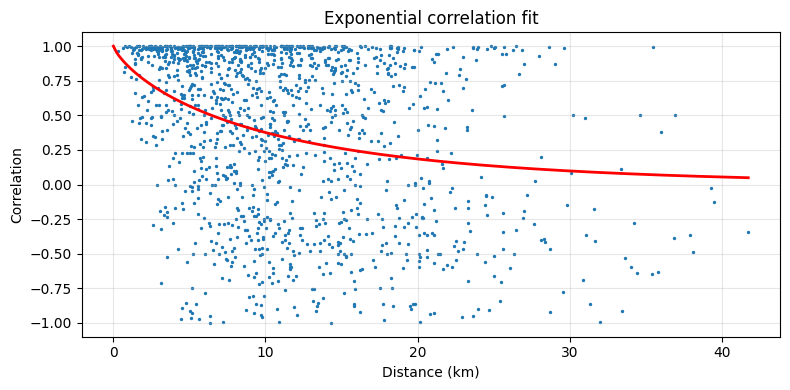

Estimated range a = 10.283 km
Estimated shape b = 0.787


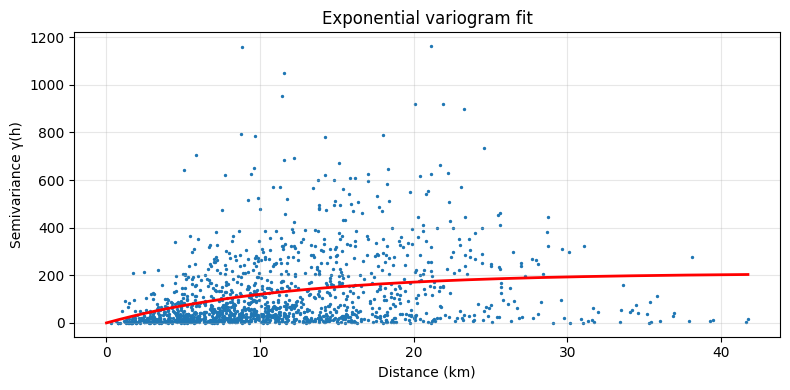

Estimated sill = 209.174
Estimated range = 11.697 km


OSError: Cannot save file into a non-existent directory: '/mnt/12TB/Sujan/Spatial_correlation/Codes/01_Correlation_and_Variogram'

In [13]:
from pandas.errors import EmptyDataError
RAIN_DIR = Path("/mnt/12TB/Sujan/Spatial_correlation/Codes/Compiled_rain/compiled_rawstyle_hourly_mm/per_station_hourly/")
FILE_SUFFIX = ".hourly_mm.csv"
GAP_DIR = Path("/mnt/12TB/Sujan/Spatial_correlation/Codes/dependent_files/Missing_gap_time")

TIME_LOCAL_COL = "time_local"
TIME_UTC_COL   = "time_utc"
RAIN_COL       = "rain_mm"
# ---------------------------------------------------------
# 1) Window defined by explicit START and END (local clock)
#    Inputs: "yyyymmddHH"
# ---------------------------------------------------------

def make_window(start_str: str, end_str: str):
    start = pd.to_datetime(start_str, format="%Y%m%d%H")
    end   = pd.to_datetime(end_str,   format="%Y%m%d%H")
    if end < start:
        raise ValueError("end_str must be >= start_str")
    idx = pd.date_range(start, end, freq="1h")
    return start, end, idx
    

# ---------------------------------------------------------
# 2) Load station rainfall indexed by naive LOCAL time
# ---------------------------------------------------------
def station_has_event_gap(station_id, event_start_local, event_end_local, gap_dir=GAP_DIR) -> bool:
    fp = gap_dir / f"{station_id}.hourly_mm_missing_ranges.csv"
    if not fp.exists():
        return False
    
    try:
        g = pd.read_csv(fp, sep=None, engine="python")
    except EmptyDataError:
        print(f"[WARN] Empty gap file: {fp}")
        return False
    except Exception as e:
        print(f"[WARN] Could not read gap file: {fp}")
        print(e)
        return False
    
    if g.empty:
        print(f"[WARN] Gap file has no rows: {fp}")
        return False

    # Parse as tz-aware (because strings include -0600), convert to Chicago, then drop tz
    tz_local = "America/Chicago"

    gs = pd.to_datetime(g["gap_start_local"], errors="coerce", utc=True).dt.tz_convert(tz_local).dt.tz_localize(None)
    ge = pd.to_datetime(g["gap_end_local"],   errors="coerce", utc=True).dt.tz_convert(tz_local).dt.tz_localize(None)

    g = g.assign(gap_start_local=gs, gap_end_local=ge).dropna(subset=["gap_start_local", "gap_end_local"])
    if g.empty:
        return False

    # Ensure event is also naive local time
    event_start_local = pd.Timestamp(event_start_local).tz_localize(None)
    event_end_local   = pd.Timestamp(event_end_local).tz_localize(None)

    overlap = (event_start_local <= g["gap_end_local"]) & (event_end_local >= g["gap_start_local"])
    return bool(overlap.any())
    
def load_station_series_local(station_id: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.Series:
    fp = RAIN_DIR / f"{station_id}{FILE_SUFFIX}"
    if not fp.exists():
        raise FileNotFoundError(fp)

    df = pd.read_csv(fp, usecols=[TIME_LOCAL_COL, TIME_UTC_COL, RAIN_COL])

    # Parse UTC
    t_utc = pd.to_datetime(df[TIME_UTC_COL], utc=True, errors="coerce")

    # Extract offset like -0600 -> -06 hours
    off = df[TIME_LOCAL_COL].astype(str).str.extract(r"([+-]\d{2})\d{2}$")[0]
    off_hours = pd.to_numeric(off, errors="coerce")

    # UTC -> local naive timestamp
    t_local = (t_utc + pd.to_timedelta(off_hours, unit="h")).dt.tz_localize(None)

    # Build series
    s = pd.Series(pd.to_numeric(df[RAIN_COL], errors="coerce").to_numpy(), index=t_local)

    # --- FIX: collapse duplicate timestamps (same local hour) ---
    # Use mean (or sum if you know they are increments)
    s = s.groupby(level=0).mean()

    # subset + ensure hourly index
    s = s.sort_index().loc[start:end]

    # If there are non-hourly stamps, force to hourly by grouping again
    # (safe even if already hourly)
    s = s.groupby(s.index.floor("h")).mean()

    return s


# ---------------------------------------------------------
# 3) Build Z for stations in your buffer for [start,end]
#    Drops all-NaN rows, drops rows where all stations are 0/NaN,
#    then fills remaining NaN with 0 (as you requested)
# ---------------------------------------------------------


def build_rain_matrix_for_period(
    start_str: str,
    end_str: str,
    station_ok: dict[str, bool],
):
    start, end, full_index = make_window(start_str, end_str)

    station_ids_all = stations_in_km["ID"].astype(str).unique().tolist()

    # filter stations BEFORE loading rainfall
    station_ids = [sid for sid in station_ids_all if station_ok.get(sid, True)]
    print(f"Stations in buffer: {len(station_ids_all)} | after gap-filter: {len(station_ids)}")

    cols = {}
    for sid in station_ids:
        try:
            s = load_station_series_local(sid, start, end)
        except FileNotFoundError:
            print(f"[WARN] missing file for station {sid}")
            continue

        cols[sid] = s.reindex(full_index)

    Z = pd.DataFrame(cols, index=full_index)

    # Drop stations entirely missing (all NaN)
    Z = Z.dropna(axis=1, how="all")

    # Drop hours where all stations missing
    Z = Z.dropna(axis=0, how="all")

    print("Hours:", Z.shape[0], "Stations:", Z.shape[1])

    # Save raw Z WITH NaNs (recommended for correlation/variogram)
    Z.to_csv(f"/mnt/12TB/Sujan/Spatial_correlation/Codes/UTM_OK/Correlation_Variogram_exports/Z_{start_str}_rawNaN.csv")

    return Z


# ---------------------------------------------------------
# 4) Pair table from distance matrix (NO BINNING)
# ---------------------------------------------------------
def make_pairs_table(Dsub: pd.DataFrame) -> pd.DataFrame:
    ids = Dsub.index.astype(str).tolist()
    rows = []
    for a in range(len(ids)):
        for b in range(a + 1, len(ids)):
            i, j = ids[a], ids[b]
            d = float(Dsub.loc[i, j])
            rows.append((i, j, d))
    return pd.DataFrame(rows, columns=["id_i", "id_j", "dist_m"])

# ---------------------------------------------------------
# 5) Pairwise correlation + semivariance + mean-removed variogram
# ---------------------------------------------------------
def build_station_event_ok_map(
    station_ids: list[str],
    event_start_local: pd.Timestamp,
    event_end_local: pd.Timestamp,
) -> dict[str, bool]:
    ok = {}
    for sid in station_ids:
        ok[sid] = not station_has_event_gap(sid, event_start_local, event_end_local)
    return ok
    
def compute_pair_stats(
    Z: pd.DataFrame,
    Dsub: pd.DataFrame,
    min_hrs: int,
    min_samples: int,
) -> pd.DataFrame:

    ids = Z.columns.astype(str).tolist()
    out = []

    for a in range(len(ids)):
        for b in range(a + 1, len(ids)):

            i, j = ids[a], ids[b]

            if i not in Dsub.index or j not in Dsub.columns:
                continue

            d = float(Dsub.loc[i, j])

            xi = Z[i]
            xj = Z[j]

            # only overlapping non-NaN hours
            m = xi.notna() & xj.notna()
            xi2 = xi[m]
            xj2 = xj[m]

            n = len(xi2)
            if n < min_samples:
                continue

            rain_hours_i = (xi2 > 0).sum()
            rain_hours_j = (xj2 > 0).sum()
            if rain_hours_i < min_hrs or rain_hours_j < min_hrs:
                continue

            corr_ij = xi2.corr(xj2)
            gamma_ij = 0.5 * ((xi2 - xj2) ** 2).mean()

            out.append((i, j, d, n, corr_ij, gamma_ij))

    return pd.DataFrame(out, columns=["id_i", "id_j", "dist_m", "n_overlap", "corr", "gamma"])

def exponential_corr_model(h, a, b):
    """
    Exponential correlation model:
    rho(h) = exp( - (h/a)^b )
    h in km
    """
    return np.exp(- (h / a) ** b)
def exponential_variogram_model(h, sill, a):
    return sill * (1 - np.exp(-h / a))

def plot_results(event_number,pair_stats, start_str, end_str, degree=2):

    p_corr = pair_stats.dropna(subset=["corr"])

    if len(p_corr) < 3:
        print("Not enough correlation points to fit model.")
    else:
        x = p_corr["dist_m"].values / 1000.0  # km
        y = p_corr["corr"].values

        # initial guesses
        p0 = [20, 1]  # a=20 km range, b=1 shape

        popt, _ = curve_fit(exponential_corr_model, x, y, p0=p0, maxfev=5000)

        a_est, b_est = popt
        xs = np.linspace(0, x.max(), 200)
        ys = exponential_corr_model(xs, a_est, b_est)

        plt.figure(figsize=(8,4))
        plt.scatter(x, y, s=2)
        plt.plot(xs, ys, linewidth=2,color="red")
        plt.xlabel("Distance (km)")
        plt.ylabel("Correlation")
        plt.title(f"Exponential correlation fit")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        print(f"Estimated range a = {a_est:.3f} km")
        print(f"Estimated shape b = {b_est:.3f}")

    # ---- Variogram
    x = pair_stats["dist_m"].values / 1000.0
    y = pair_stats["gamma"].values

    p0 = [y.max(), 20]

    popt, _ = curve_fit(exponential_variogram_model, x, y, p0=p0, maxfev=5000)
    sill_est, a_est_var = popt

    xs = np.linspace(0, x.max(), 200)
    ys = exponential_variogram_model(xs, sill_est, a_est_var)

    plt.figure(figsize=(8,4))
    plt.scatter(x, y, s=2)
    plt.plot(xs, ys, linewidth=2,color="red")
    plt.xlabel("Distance (km)")
    plt.ylabel("Semivariance γ(h)")
    plt.title(f"Exponential variogram fit")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Estimated sill = {sill_est:.3f}")
    print(f"Estimated range = {a_est_var:.3f} km")
    
    station_cols = None
    for c1, c2 in [
        ("station_i", "station_j"),
        ("gauge_i", "gauge_j"),
        ("sta_i", "sta_j"),
        ("site_i", "site_j"),
        ("s1", "s2"),
        ("id_i", "id_j"),   
    ]:
        if c1 in pair_stats.columns and c2 in pair_stats.columns:
            station_cols = (c1, c2)
            break

    if station_cols is not None:
        stations_selected = pd.unique(
            pd.concat([pair_stats[station_cols[0]], pair_stats[station_cols[1]]], axis=0).dropna()
        ).tolist()
    else:
        # fallback for your "g1..g7" style selection table, if present
        gcols = [c for c in pair_stats.columns if c.lower().startswith("g") and c[1:].isdigit()]
        if gcols:
            stations_selected = pd.unique(pair_stats[gcols].stack().dropna()).tolist()
        else:
            stations_selected = []

    stations_selected = sorted(stations_selected)
    
    out_df = pd.DataFrame([{
        "event_number": event_number,
        "event_start": start_str,
        "event_end":end_str,
        "stations_selected": stations_selected,
        "corr_a_km": float(a_est) if np.isfinite(a_est) else np.nan,
        "corr_b": float(b_est) if np.isfinite(b_est) else np.nan,
        "selections": stations_selected,  # "list of all the selection for the event"
    }])

    return out_df

# ---------------------------------------------------------
# 6) Main runner using START/END (no center)
# ---------------------------------------------------------
def run_period(event, start_str: str, end_str: str, hour_limit):

    event_start_local = pd.to_datetime(start_str, format="%Y%m%d%H")
    event_end_local   = pd.to_datetime(end_str,   format="%Y%m%d%H")

    # station ids from buffer list (no file reads yet)
    station_ids_all = stations_in_km["ID"].astype(str).unique().tolist()

    # build ok map once (gap overlap check)
    station_ok = build_station_event_ok_map(
        station_ids=station_ids_all,
        event_start_local=event_start_local,
        event_end_local=event_end_local,
    )

    # build Z using only stations that pass gap check
    Z = build_rain_matrix_for_period(start_str, end_str, station_ok)

    if Z.shape[1] < 4:
        raise RuntimeError("Too few stations with usable data after gap-filter")

    ids = Z.columns.astype(str)
    Dsub = distance_matrix.loc[ids, ids]

    pair_stats = compute_pair_stats(Z, Dsub, hour_limit, hour_limit)

    correlation_result = plot_results(event, pair_stats, start_str, end_str)

    return Z, pair_stats, correlation_result

# -------------------------
# Event 1
Z, pair_stats,correlation_result = run_period(1,"2013053012", "2013053112",5)
correlation_result.to_csv("/mnt/12TB/Sujan/Spatial_correlation/Codes/UTM_OK/01_Correlation_and_Variogram/Event_1_Stations_correlation.csv")

# Event 2
Z, pair_stats,correlation_result = run_period(2,"2014080612", "2014080712",5)
correlation_result.to_csv("/mnt/12TB/Sujan/Spatial_correlation/Codes/UTM_OK/01_Correlation_and_Variogram/Event_2_Stations_correlation.csv")
# Event 3
Z, pair_stats,correlation_result = run_period(3,"2015091100", "2015091112",4)
correlation_result.to_csv("/mnt/12TB/Sujan/Spatial_correlation/Codes/UTM_OK/01_Correlation_and_Variogram/Event_3_Stations_correlation.csv")
# Event 4
Z, pair_stats,correlation_result = run_period(4,"2016042607", "2016042712",5)
correlation_result.to_csv("/mnt/12TB/Sujan/Spatial_correlation/Codes/UTM_OK/01_Correlation_and_Variogram/Event_4_Stations_correlation.csv")
# Event 5
Z, pair_stats,correlation_result = run_period(5,"2016082606", "2016082712",6)
correlation_result.to_csv("/mnt/12TB/Sujan/Spatial_correlation/Codes/UTM_OK/01_Correlation_and_Variogram/Event_5_Stations_correlation.csv")
# Event 6
Z, pair_stats,correlation_result = run_period(6,"2017072300", "2017072312",3)
correlation_result.to_csv("/mnt/12TB/Sujan/Spatial_correlation/Codes/UTM_OK/01_Correlation_and_Variogram/Event_6_Stations_correlation.csv")
# Event 7
Z, pair_stats,correlation_result = run_period(7,"2017072617", "2017072712",9)
correlation_result.to_csv("/mnt/12TB/Sujan/Spatial_correlation/Codes/UTM_OK/01_Correlation_and_Variogram/Event_7_Stations_correlation.csv")
# Event 8
Z, pair_stats,correlation_result = run_period(8,"2017082112", "2017082212",8)
correlation_result.to_csv("/mnt/12TB/Sujan/Spatial_correlation/Codes/UTM_OK/01_Correlation_and_Variogram/Event_8_Stations_correlation.csv")
# Event 9
Z, pair_stats,correlation_result = run_period(9,"2018071721", "2018071816",3)
correlation_result.to_csv("/mnt/12TB/Sujan/Spatial_correlation/Codes/01_Correlation_and_Variogram/Event_9_Stations_correlation.csv")
# Event 10
Z, pair_stats,correlation_result = run_period(10,"2019082511", "2019082617",5)
correlation_result.to_csv("/mnt/12TB/Sujan/Spatial_correlation/Codes/UTM_OK/01_Correlation_and_Variogram/Event_10_Stations_correlation.csv")